# Notebook 05 — Pipeline Completo (ao vivo na webcam)

## Objetivo

Juntar tudo: **abrir webcam → detectar → embedar → comparar contra base → desenhar nome**.

Este notebook é o **protótipo funcional** do que vai virar o PWA do tablet. Mesma lógica, escrita em Python pra você entender cada etapa.

## Como usar

1. Rode as células de setup.
2. Rode a célula "capturar foto" — ela tira **uma foto** com countdown de 5s.
3. O notebook detecta, identifica e mostra resultado anotado.

> Por que **uma foto** em vez de loop ao vivo? Porque Jupyter + OpenCV ao vivo é frustrante (`cv2.imshow` trava). O *loop* ao vivo vem no `attendance/run.py` do Sprint 2.

## Recapitulação rápida

| Etapa | Notebook | O que aprendemos |
|---|---|---|
| Detecção | 01 | HOG rápido / CNN robusto, qual usar em cada contexto |
| Landmarks + alinhamento | 02 | Rotacionar olhos pra horizontal antes do embedding |
| Embedding 128-D | 03 | Cada rosto vira vetor; distância separa pessoas |
| Threshold | 04 | `0.55` escolhido — FAR baixo prioritário |

## 1. Setup e carregamento da base de embeddings

In [3]:
import time
from pathlib import Path

import cv2
import face_recognition
import matplotlib.pyplot as plt
import numpy as np

DATASET_DIR = Path('../dataset')
THRESHOLD = 0.55  # Notebook 04 / docs/THRESHOLD.md

base = {}
for pessoa_dir in sorted(DATASET_DIR.iterdir()):
    if not pessoa_dir.is_dir():
        continue
    encs = []
    for f in sorted(list(pessoa_dir.glob('*.jp*g')) + list(pessoa_dir.glob('*.png'))):
        img = face_recognition.load_image_file(f)
        locs = face_recognition.face_locations(img, model='hog')
        if locs:
            encs.append(face_recognition.face_encodings(img, locs)[0])
    if encs:
        base[pessoa_dir.name] = np.mean(encs, axis=0)
        print(f'  {pessoa_dir.name}: {len(encs)} fotos → 1 embedding médio')
print(f'\nBase carregada com {len(base)} pessoa(s).')

  diogo: 5 fotos → 1 embedding médio

Base carregada com 1 pessoa(s).


### Sobre embedding médio

Em vez de guardar 1 embedding por foto e fazer N comparações, calculamos a **média** dos embeddings de cada pessoa. Isso:

- Reduz ruído (cada foto tem variações de pose/luz).
- Torna a comparação O(K) onde K = nº de pessoas, não O(K×F) onde F = fotos por pessoa.
- Vale porque a média no espaço de embeddings ainda representa bem a pessoa (propriedade aprendida durante treino do FaceNet).

## 2. Capturar foto da webcam

Posicione o rosto:
  5...
  4...
  3...
  2...
  1...
Frame capturado: (480, 640, 3)


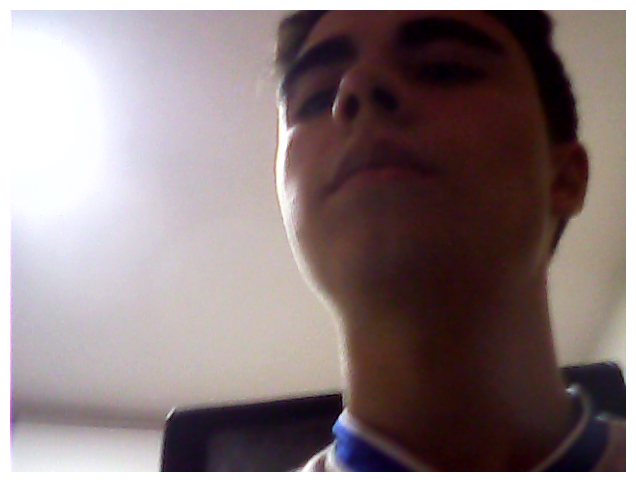

In [4]:
def capturar(countdown=5):
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError('Webcam não abriu')
    for _ in range(10):
        cap.read(); time.sleep(0.05)
    print('Posicione o rosto:')
    for i in range(countdown, 0, -1):
        print(f'  {i}...', flush=True); time.sleep(1)
    ok, frame_bgr = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError('Falha na captura')
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

frame = capturar(countdown=5)
print(f'Frame capturado: {frame.shape}')
plt.figure(figsize=(8, 6)); plt.imshow(frame); plt.axis('off'); plt.show()

## 3. Pipeline completo aplicado ao frame

In [5]:
def identificar(frame_rgb, base, threshold):
    """Devolve lista de (box, nome, distância). Nome=None se desconhecido."""
    locs = face_recognition.face_locations(frame_rgb, model='hog')
    if not locs:
        return []
    encs = face_recognition.face_encodings(frame_rgb, locs)
    nomes = list(base.keys())
    matriz_ref = np.stack([base[n] for n in nomes])
    resultados = []
    for box, enc in zip(locs, encs):
        dists = np.linalg.norm(matriz_ref - enc, axis=1)
        idx = int(np.argmin(dists))
        d = float(dists[idx])
        nome = nomes[idx] if d < threshold else None
        resultados.append((box, nome, d))
    return resultados

resultados = identificar(frame, base, THRESHOLD)
print(f'Detectou {len(resultados)} rosto(s):')
for (top, right, bottom, left), nome, d in resultados:
    status = nome if nome else 'DESCONHECIDO'
    print(f'  caixa=({left},{top})-({right},{bottom})  dist={d:.3f}  →  {status}')

Detectou 0 rosto(s):


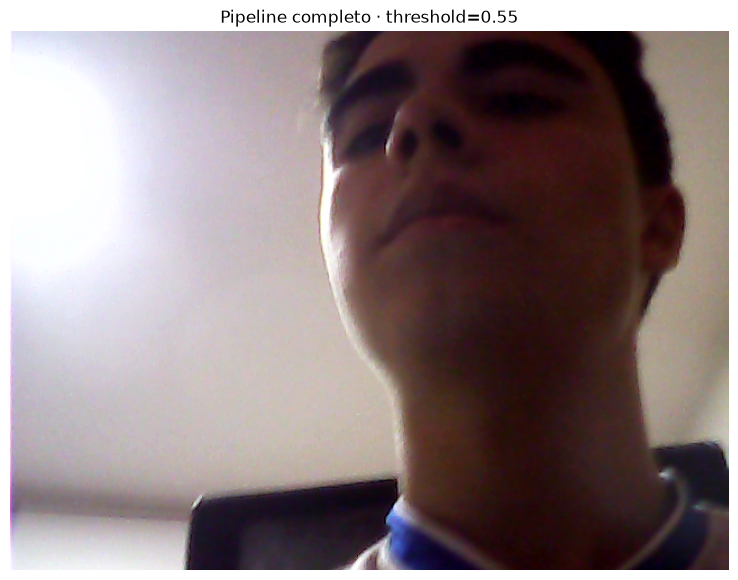

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(frame)
for (top, right, bottom, left), nome, d in resultados:
    cor = 'lime' if nome else 'red'
    ax.add_patch(plt.Rectangle((left, top), right-left, bottom-top, fill=False, color=cor, linewidth=3))
    label = f'{nome} ({d:.2f})' if nome else f'? ({d:.2f})'
    ax.text(left, top-10, label, color=cor, fontsize=12, weight='bold',
            bbox=dict(facecolor='black', alpha=0.6))
ax.set_title(f'Pipeline completo · threshold={THRESHOLD}')
ax.axis('off'); plt.show()

## 4. Conclusão do Sprint 1

Você acabou de:

- ✅ Implementar e entender **detecção** facial (HOG vs CNN).
- ✅ Extrair **68 landmarks** e fazer **alinhamento** por olhos.
- ✅ Gerar **embeddings 128-D** e visualizar separação em 2D (PCA).
- ✅ Medir **FAR/FRR**, encontrar **EER** e justificar threshold.
- ✅ Compor o **pipeline completo** com base + comparação por distância.

Esse é o conteúdo de ciência de dados que você pode levar pro relatório do projeto de extensão.

## 5. Próximo: Sprint 2

- `enrollment/enroll.py` — cadastro com webcam.
- `attendance/logic.py` — SQLite + check-in/out alternado + debounce.
- `attendance/run.py` — loop ao vivo de verdade.
